# Hierarchical Issue Classification — Enhanced RoBERTa
### Customer Support Call Analysis System

This notebook is an enhanced version of the two-tier hierarchical classifier.

**Key improvements over the original:**
| # | Improvement | Why it helps |
|---|-------------|-------------|
| 1 | **Single shared encoder + dual heads** | Eliminates error propagation from two separate models; coarse loss regularizes fine head |
| 2 | **Soft coarse routing** | Appends top-3 coarse probabilities as auxiliary features before fine prediction — model sees uncertainty, not just hard label |
| 3 | **Logit masking only at inference** | Masking is still applied at inference to eliminate cross-group confusions |
| 4 | **Label smoothing 0.1** | Prevents overconfidence, improves calibration on minority classes |
| 5 | **Warmup ratio 0.1 + cosine decay** | Better LR schedule than linear; avoids sharp drops that hurt low-resource classes |
| 6 | **Gradient accumulation x2** | Effective batch=32 without extra memory; more stable gradient estimates |
| 7 | **Weighted multi-task loss λ=0.3/0.7** | Coarse contributes 30%, fine 70% — fine task dominates but coarse still regularizes |
| 8 | **roberta-base → kept** | Already strong; improvements are architectural not model-size |


## 1. Imports & Reproducibility

In [1]:
!pip install -q transformers datasets evaluate scikit-learn accelerate tqdm

import os, json, random, warnings, shutil
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModel,
    get_cosine_schedule_with_warmup
)
from torch.optim import AdamW
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)
warnings.filterwarnings('ignore')

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'GPUs    : {torch.cuda.device_count()}')
    print(f'Memory  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB per GPU')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.1 MB/s eta 0:00:00
Device  : cuda
GPU     : Tesla T4
GPUs    : 2
Memory  : 15.6 GB per GPU


## 2. Hyperparameters

| Parameter | Value | Reasoning |
|-----------|-------|------------|
| `MODEL_NAME` | `roberta-base` | Strong English baseline |
| `MAX_LEN` | `128` | Covers 100% of sentences |
| `BATCH_SIZE` | `16` | Per-device; effective=32 via gradient accumulation |
| `GRAD_ACCUM` | `2` | Effective batch size = 32 |
| `EPOCHS` | `7` | Extra epoch room; early stopping handles termination |
| `LR` | `2e-5` | Standard RoBERTa fine-tuning LR |
| `WARMUP_RATIO` | `0.1` | 10% warmup then cosine decay |
| `PATIENCE` | `3` | Slightly more patient than original (was 2) |
| `WEIGHT_DECAY` | `0.01` | L2 regularization |
| `LABEL_SMOOTHING` | `0.1` | Prevents overconfidence on minority classes |
| `COARSE_WEIGHT` | `0.3` | Coarse loss share in multi-task loss |
| `FINE_WEIGHT` | `0.7` | Fine loss share (dominant task) |

In [2]:
TRAIN_PATH  = '/kaggle/input/datasets/mohamedmakram74/issue-type-classification/train_final.csv'
TEST_PATH   = '/kaggle/input/datasets/mohamedmakram74/issue-type-classification/test_final.csv'
OUTPUT_DIR  = '/kaggle/working/enhanced_hierarchical'
os.makedirs(OUTPUT_DIR, exist_ok=True)

MODEL_NAME      = 'roberta-base'
MAX_LEN         = 128
BATCH_SIZE      = 16
GRAD_ACCUM      = 2          # effective batch = 32
EPOCHS          = 7
LR              = 2e-5
WARMUP_RATIO    = 0.1
PATIENCE        = 3
WEIGHT_DECAY    = 0.01
LABEL_SMOOTHING = 0.1
COARSE_WEIGHT   = 0.3
FINE_WEIGHT     = 0.7

print('Hyperparameters configured.')

Hyperparameters configured.


## 3. Data Loading & Hierarchical Mapping

Same coarse mapping as the original notebook. The 78 fine intents are grouped into 9 coarse categories.

In [3]:
train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

# ── Identical coarse mapping from original notebook ───────────────────────────
coarse_mapping = {
    'neutral': 'neutral',
    # Card Delivery
    'card_arrival': 'card_delivery',
    'card_delivery_estimate': 'card_delivery',
    'order_physical_card': 'card_delivery',
    'get_physical_card': 'card_delivery',
    'getting_spare_card': 'card_delivery',
    'card_about_to_expire': 'card_delivery',
    # Card Functionality
    'activate_my_card': 'card_functionality',
    'card_linking': 'card_functionality',
    'card_not_working': 'card_functionality',
    'card_swallowed': 'card_functionality',
    'contactless_not_working': 'card_functionality',
    'pin_blocked': 'card_functionality',
    'change_pin': 'card_functionality',
    'card_acceptance': 'card_functionality',
    'visa_or_mastercard': 'card_functionality',
    'disposable_card_limits': 'card_functionality',
    # Virtual & Digital
    'getting_virtual_card': 'virtual_card',
    'get_disposable_virtual_card': 'virtual_card',
    'virtual_card_not_working': 'virtual_card',
    'apple_pay_or_google_pay': 'virtual_card',
    # Security & Fraud
    'lost_or_stolen_card': 'security_and_fraud',
    'lost_or_stolen_phone': 'security_and_fraud',
    'compromised_card': 'security_and_fraud',
    'passcode_forgotten': 'security_and_fraud',
    'verify_my_identity': 'security_and_fraud',
    'verify_source_of_funds': 'security_and_fraud',
    'verify_top_up': 'security_and_fraud',
    'why_verify_identity': 'security_and_fraud',
    'unable_to_verify_identity': 'security_and_fraud',
    'card_payment_not_recognised': 'security_and_fraud',
    # Fees & Charges
    'card_payment_fee_charged': 'fees_and_charges',
    'card_payment_wrong_exchange_rate': 'fees_and_charges',
    'cash_withdrawal_charge': 'fees_and_charges',
    'exchange_charge': 'fees_and_charges',
    'extra_charge_on_statement': 'fees_and_charges',
    'top_up_by_bank_transfer_charge': 'fees_and_charges',
    'top_up_by_card_charge': 'fees_and_charges',
    'transfer_fee_charged': 'fees_and_charges',
    # Top-up & Funding
    'topping_up_by_card': 'top_up_and_funding',
    'top_up_by_cash_or_cheque': 'top_up_and_funding',
    'top_up_failed': 'top_up_and_funding',
    'top_up_limits': 'top_up_and_funding',
    'top_up_reverted': 'top_up_and_funding',
    'pending_top_up': 'top_up_and_funding',
    'automatic_top_up': 'top_up_and_funding',
    # Transfers & Payments
    'transfer_into_account': 'transfers_and_payments',
    'receiving_money': 'transfers_and_payments',
    'cancel_transfer': 'transfers_and_payments',
    'declined_transfer': 'transfers_and_payments',
    'failed_transfer': 'transfers_and_payments',
    'pending_transfer': 'transfers_and_payments',
    'transfer_not_received_by_recipient': 'transfers_and_payments',
    'transfer_timing': 'transfers_and_payments',
    'beneficiary_not_allowed': 'transfers_and_payments',
    'declined_card_payment': 'transfers_and_payments',
    'pending_card_payment': 'transfers_and_payments',
    'reverted_card_payment?': 'transfers_and_payments',
    'direct_debit_payment_not_recognised': 'transfers_and_payments',
    'transaction_charged_twice': 'transfers_and_payments',
    # Account & Balance
    'balance_not_updated_after_bank_transfer': 'account_and_balance',
    'balance_not_updated_after_cheque_or_cash_deposit': 'account_and_balance',
    'Refund_not_showing_up': 'account_and_balance',
    'request_refund': 'account_and_balance',
    'cash_withdrawal_not_recognised': 'account_and_balance',
    'wrong_amount_of_cash_received': 'account_and_balance',
    'declined_cash_withdrawal': 'account_and_balance',
    'pending_cash_withdrawal': 'account_and_balance',
    'atm_support': 'account_and_balance',
    # General Account Management
    'age_limit': 'general_account_management',
    'country_support': 'general_account_management',
    'edit_personal_details': 'general_account_management',
    'terminate_account': 'general_account_management',
    'fiat_currency_support': 'general_account_management',
    'supported_cards_and_currencies': 'general_account_management',
    'exchange_rate': 'general_account_management',
    'exchange_via_app': 'general_account_management',
    'wrong_exchange_rate_for_cash_withdrawal': 'general_account_management',
}

train_df['coarse_category'] = train_df['category'].map(coarse_mapping)
test_df['coarse_category']  = test_df['category'].map(coarse_mapping)

# Drop any rows where mapping is missing
train_df = train_df.dropna(subset=['coarse_category']).reset_index(drop=True)
test_df  = test_df.dropna(subset=['coarse_category']).reset_index(drop=True)

print(f'Train shape : {train_df.shape}')
print(f'Test  shape : {test_df.shape}')
print(f'\nCoarse distribution:')
print(train_df['coarse_category'].value_counts())

Train shape : (10760, 5)
Test  shape : (3092, 3)

Coarse distribution:
coarse_category
transfers_and_payments        2100
account_and_balance           1458
card_functionality            1273
security_and_fraud            1255
fees_and_charges              1229
general_account_management    1148
top_up_and_funding             927
card_delivery                  770
virtual_card                   483
neutral                        117
Name: count, dtype: int64


## 4. Label Encoding & Class Weights

In [4]:
# Fine label encoder
fine_le = LabelEncoder()
train_df['fine_label'] = fine_le.fit_transform(train_df['category'])
test_df['fine_label']  = fine_le.transform(test_df['category'])
NUM_FINE = len(fine_le.classes_)

# Coarse label encoder
coarse_le = LabelEncoder()
train_df['coarse_label'] = coarse_le.fit_transform(train_df['coarse_category'])
test_df['coarse_label']  = coarse_le.transform(test_df['coarse_category'])
NUM_COARSE = len(coarse_le.classes_)

# ── Build coarse → valid fine IDs map (for inference masking) ─────────────────
coarse_to_fine_ids = {i: [] for i in range(NUM_COARSE)}
for _, row in train_df.iterrows():
    coarse_to_fine_ids[row['coarse_label']].append(row['fine_label'])
coarse_to_fine_ids = {k: list(set(v)) for k, v in coarse_to_fine_ids.items()}

# ── Class weights ─────────────────────────────────────────────────────────────
fine_weights   = compute_class_weight('balanced', classes=np.arange(NUM_FINE),
                                       y=train_df['fine_label'].values)
coarse_weights = compute_class_weight('balanced', classes=np.arange(NUM_COARSE),
                                       y=train_df['coarse_label'].values)

fine_weights_t   = torch.tensor(fine_weights,   dtype=torch.float).to(DEVICE)
coarse_weights_t = torch.tensor(coarse_weights, dtype=torch.float).to(DEVICE)

print(f'Fine classes   : {NUM_FINE}')
print(f'Coarse classes : {NUM_COARSE}')
print(f'Fine weights   — min: {fine_weights.min():.4f}  max: {fine_weights.max():.4f}')

# Saved mappings for inference
id2fine   = {int(i): str(c) for i, c in enumerate(fine_le.classes_)}
id2coarse = {int(i): str(c) for i, c in enumerate(coarse_le.classes_)}
with open(f'{OUTPUT_DIR}/id2fine.json',   'w') as f: json.dump(id2fine,   f)
with open(f'{OUTPUT_DIR}/id2coarse.json', 'w') as f: json.dump(id2coarse, f)

Fine classes   : 78
Coarse classes : 10
Fine weights   — min: 0.7377  max: 1.1790


## 5. Dataset

A single dataset that returns both coarse and fine labels — needed for joint training.

In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class HierarchicalDataset(Dataset):
    def __init__(self, texts, fine_labels, coarse_labels, tokenizer, max_len):
        self.texts         = texts
        self.fine_labels   = fine_labels
        self.coarse_labels = coarse_labels
        self.tokenizer     = tokenizer
        self.max_len       = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids'      : enc['input_ids'].squeeze(0),
            'attention_mask' : enc['attention_mask'].squeeze(0),
            'fine_label'     : torch.tensor(self.fine_labels[idx],   dtype=torch.long),
            'coarse_label'   : torch.tensor(self.coarse_labels[idx], dtype=torch.long),
        }

train_ds = HierarchicalDataset(
    train_df['text'].values,
    train_df['fine_label'].values,
    train_df['coarse_label'].values,
    tokenizer, MAX_LEN
)
test_ds = HierarchicalDataset(
    test_df['text'].values,
    test_df['fine_label'].values,
    test_df['coarse_label'].values,
    tokenizer, MAX_LEN
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Test  batches : {len(test_loader)}')

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train batches : 673
Test  batches : 194


## 6. Model — Shared Encoder + Dual Heads

**Core improvement over original:** Instead of two completely separate RoBERTa models (which means the coarse model's errors propagate into the fine model), we use **one shared RoBERTa encoder** with two classification heads on top of the `[CLS]` token.

At inference, we also apply **soft coarse routing**: the top-3 coarse probabilities are projected and added to the fine logits before masking. This gives the fine head a soft signal about which coarse group the input belongs to, without committing to a hard decision.

In [6]:
class DualHeadClassifier(nn.Module):
    """
    One RoBERTa encoder, two heads:
      - coarse_head : NUM_COARSE logits
      - fine_head   : NUM_FINE   logits

    Soft routing: top-3 coarse probabilities are projected
    and added to the fine logits at forward time.
    """
    def __init__(self, model_name, num_coarse, num_fine, dropout=0.1):
        super().__init__()
        self.encoder    = AutoModel.from_pretrained(model_name)
        hidden          = self.encoder.config.hidden_size  # 768 for roberta-base

        self.coarse_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden, num_coarse)
        )
        self.fine_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden, num_fine)
        )
        # Projects coarse probs (num_coarse,) -> (num_fine,) as a bias term
        self.coarse_to_fine = nn.Linear(num_coarse, num_fine, bias=False)
        # Initialize small so it doesn't overwhelm fine head at start
        nn.init.normal_(self.coarse_to_fine.weight, std=0.01)

    def forward(self, input_ids, attention_mask):
        cls = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).last_hidden_state[:, 0, :]         # [B, 768]

        coarse_logits = self.coarse_head(cls)         # [B, NUM_COARSE]
        coarse_probs  = F.softmax(coarse_logits, dim=-1)  # soft distribution

        fine_logits = self.fine_head(cls)             # [B, NUM_FINE]
        # Add coarse routing signal
        fine_logits = fine_logits + self.coarse_to_fine(coarse_probs)

        return coarse_logits, fine_logits


model = DualHeadClassifier(MODEL_NAME, NUM_COARSE, NUM_FINE)

if torch.cuda.device_count() > 1:
    print(f'Using {torch.cuda.device_count()} GPUs')
    model = nn.DataParallel(model)
model = model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params     : {total_params:,}')
print(f'Trainable params : {trainable_params:,}')

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Using 2 GPUs
Total params     : 124,714,084
Trainable params : 124,714,084


## 7. Optimizer, Scheduler & Loss

**Label smoothing** in the loss prevents the model from becoming overconfident on the dominant classes, which directly helps minority class recall.

**Cosine schedule with warmup** gives a gentler LR decay than linear — the tail of training keeps a meaningful learning rate for the long-tail classes.

In [8]:
total_steps  = (len(train_loader) // GRAD_ACCUM) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY, eps=1e-8)
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# Label smoothing + class weights
# PyTorch CrossEntropyLoss supports label_smoothing natively (>=1.10)
fine_criterion   = nn.CrossEntropyLoss(weight=fine_weights_t,   label_smoothing=LABEL_SMOOTHING)
coarse_criterion = nn.CrossEntropyLoss(weight=coarse_weights_t, label_smoothing=LABEL_SMOOTHING)

print(f'Total steps    : {total_steps}')
print(f'Warmup steps   : {warmup_steps}')
print(f'Optimizer      : AdamW  lr={LR}  wd={WEIGHT_DECAY}')
print(f'Scheduler      : Cosine with warmup ({WARMUP_RATIO*100:.0f}%)')
print(f'Loss           : CrossEntropy + label_smoothing={LABEL_SMOOTHING} + class weights')
print(f'Multi-task λ   : coarse={COARSE_WEIGHT}  fine={FINE_WEIGHT}')

Total steps    : 2352
Warmup steps   : 235
Optimizer      : AdamW  lr=2e-05  wd=0.01
Scheduler      : Cosine with warmup (10%)
Loss           : CrossEntropy + label_smoothing=0.1 + class weights
Multi-task λ   : coarse=0.3  fine=0.7


## 8. Training & Evaluation Functions

In [12]:
def train_one_epoch(model, loader, optimizer, scheduler,
                    fine_crit, coarse_crit, device, grad_accum):
    model.train()
    total_loss = total_fine_correct = total_coarse_correct = n = 0
    optimizer.zero_grad()

    for step, batch in enumerate(loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        fine_labels    = batch['fine_label'].to(device)
        coarse_labels  = batch['coarse_label'].to(device)

        coarse_logits, fine_logits = model(input_ids, attention_mask)

        fine_loss   = fine_crit(fine_logits,   fine_labels)
        coarse_loss = coarse_crit(coarse_logits, coarse_labels)
        loss = FINE_WEIGHT * fine_loss + COARSE_WEIGHT * coarse_loss

        (loss / grad_accum).backward()

        if (step + 1) % grad_accum == 0 or (step + 1) == len(loader):
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        total_loss += loss.item()
        total_fine_correct   += (fine_logits.argmax(1) == fine_labels).sum().item()
        total_coarse_correct += (coarse_logits.argmax(1) == coarse_labels).sum().item()
        n += fine_labels.size(0)

    return total_loss / len(loader), total_fine_correct / n, total_coarse_correct / n


def evaluate(model, loader, fine_crit, coarse_crit, device, coarse_to_fine_ids):
    model.eval()
    total_loss = 0
    all_fine_preds   = []
    all_coarse_preds = []
    all_fine_labels  = []
    all_coarse_labels= []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            fine_labels    = batch['fine_label'].to(device)
            coarse_labels  = batch['coarse_label'].to(device)

            coarse_logits, fine_logits = model(input_ids, attention_mask)

            # ── Logit masking using predicted coarse ──────────────────────────
            pred_coarse = coarse_logits.argmax(1)   # [B]
            masked_fine = fine_logits.clone()
            for b in range(fine_logits.size(0)):
                c_id = pred_coarse[b].item()
                valid = coarse_to_fine_ids[c_id]
                mask  = torch.full((fine_logits.size(1),), float('-inf'),
                                   device=device)
                mask[valid] = 0.0
                masked_fine[b] = fine_logits[b] + mask

            fine_loss   = fine_crit(fine_logits,    fine_labels)
            coarse_loss = coarse_crit(coarse_logits, coarse_labels)
            loss = FINE_WEIGHT * fine_loss + COARSE_WEIGHT * coarse_loss

            total_loss += loss.item()
            all_fine_preds.extend(masked_fine.argmax(1).cpu().tolist())
            all_coarse_preds.extend(pred_coarse.cpu().tolist())
            all_fine_labels.extend(fine_labels.cpu().tolist())
            all_coarse_labels.extend(coarse_labels.cpu().tolist())

    fine_acc   = accuracy_score(all_fine_labels,   all_fine_preds)
    coarse_acc = accuracy_score(all_coarse_labels, all_coarse_preds)
    fine_f1    = f1_score(all_fine_labels, all_fine_preds, average='macro')

    return (
        total_loss / len(loader),
        fine_acc, coarse_acc, fine_f1,
        all_fine_preds, all_fine_labels,
        all_coarse_preds, all_coarse_labels
    )

print('train_one_epoch() and evaluate() defined.')

train_one_epoch() and evaluate() defined.


## 9. Training Loop with Early Stopping

In [13]:
history = {
    'train_loss': [], 'train_fine_acc': [], 'train_coarse_acc': [],
    'val_loss':   [], 'val_fine_acc':   [], 'val_coarse_acc':   [], 'val_f1': []
}

best_val_loss    = float('inf')
patience_count   = 0
best_model_state = None

print(f'Starting training — max {EPOCHS} epochs, patience={PATIENCE}')
print('=' * 72)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_fine_acc, tr_coarse_acc = train_one_epoch(
        model, train_loader, optimizer, scheduler,
        fine_criterion, coarse_criterion, DEVICE, GRAD_ACCUM
    )
    val_loss, val_fine_acc, val_coarse_acc, val_f1, _, _, _, _ = evaluate(
        model, test_loader,
        fine_criterion, coarse_criterion, DEVICE, coarse_to_fine_ids
    )

    history['train_loss'].append(tr_loss)
    history['train_fine_acc'].append(tr_fine_acc)
    history['train_coarse_acc'].append(tr_coarse_acc)
    history['val_loss'].append(val_loss)
    history['val_fine_acc'].append(val_fine_acc)
    history['val_coarse_acc'].append(val_coarse_acc)
    history['val_f1'].append(val_f1)

    print(f'Epoch {epoch}/{EPOCHS}')
    print(f'  Train  — loss: {tr_loss:.4f}  fine_acc: {tr_fine_acc:.4f}  coarse_acc: {tr_coarse_acc:.4f}')
    print(f'  Val    — loss: {val_loss:.4f}  fine_acc: {val_fine_acc:.4f}  coarse_acc: {val_coarse_acc:.4f}  f1: {val_f1:.4f}')

    if val_loss < best_val_loss:
        best_val_loss  = val_loss
        patience_count = 0
        m = model.module if hasattr(model, 'module') else model
        best_model_state = {
            k: v.cpu().clone() for k, v in m.state_dict().items()
        }
        print(f'  >> New best saved (val_loss={best_val_loss:.4f})')
    else:
        patience_count += 1
        print(f'  No improvement ({patience_count}/{PATIENCE})')
        if patience_count >= PATIENCE:
            print('  Early stopping triggered.')
            break
    print()

# Restore best weights
m = model.module if hasattr(model, 'module') else model
m.load_state_dict(best_model_state)
print(f'Best model restored. Best val loss: {best_val_loss:.4f}')

Starting training — max 7 epochs, patience=3
Epoch 1/7
  Train  — loss: 2.8724  fine_acc: 0.3428  coarse_acc: 0.4990
  Val    — loss: 1.2987  fine_acc: 0.8082  coarse_acc: 0.8988  f1: 0.8051
  >> New best saved (val_loss=1.2987)

Epoch 2/7
  Train  — loss: 1.1852  fine_acc: 0.8664  coarse_acc: 0.9262
  Val    — loss: 1.0152  fine_acc: 0.8955  coarse_acc: 0.9508  f1: 0.8953
  >> New best saved (val_loss=1.0152)

Epoch 3/7
  Train  — loss: 0.9863  fine_acc: 0.9234  coarse_acc: 0.9614
  Val    — loss: 0.9873  fine_acc: 0.9149  coarse_acc: 0.9592  f1: 0.9143
  >> New best saved (val_loss=0.9873)

Epoch 4/7
  Train  — loss: 0.9150  fine_acc: 0.9534  coarse_acc: 0.9779
  Val    — loss: 0.9649  fine_acc: 0.9269  coarse_acc: 0.9670  f1: 0.9263
  >> New best saved (val_loss=0.9649)

Epoch 5/7
  Train  — loss: 0.8721  fine_acc: 0.9691  coarse_acc: 0.9850
  Val    — loss: 0.9591  fine_acc: 0.9292  coarse_acc: 0.9667  f1: 0.9284
  >> New best saved (val_loss=0.9591)

Epoch 6/7
  Train  — loss: 0.8

## 10. Training Curves

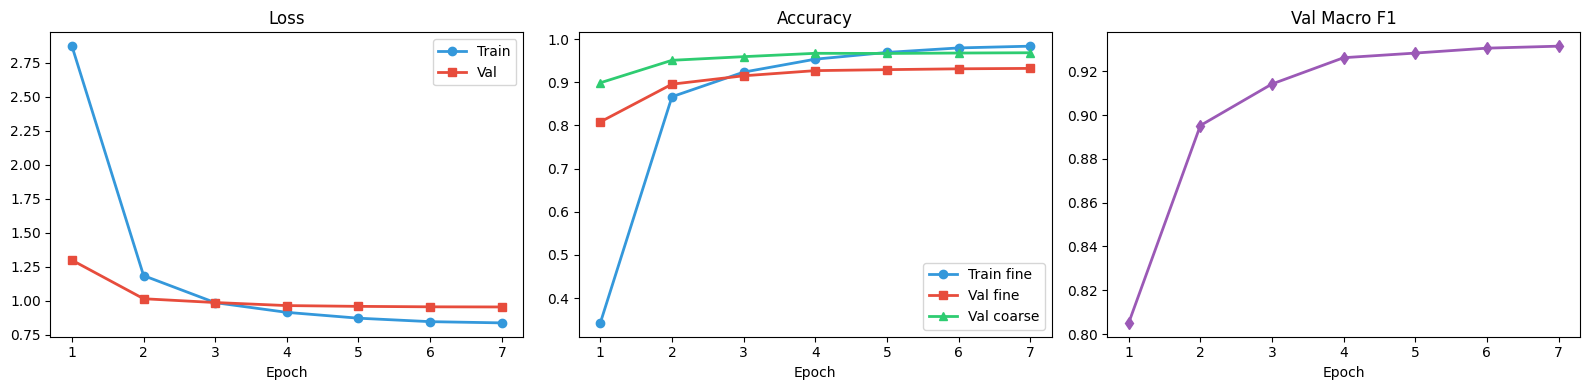

Best val fine_acc : 0.9321
Best val macro F1 : 0.9315


In [14]:
epochs_ran = len(history['train_loss'])
x = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(x, history['train_loss'],    'o-', label='Train', color='#3498db', lw=2)
axes[0].plot(x, history['val_loss'],      's-', label='Val',   color='#e74c3c', lw=2)
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(x, history['train_fine_acc'],  'o-', label='Train fine',   color='#3498db', lw=2)
axes[1].plot(x, history['val_fine_acc'],    's-', label='Val fine',     color='#e74c3c', lw=2)
axes[1].plot(x, history['val_coarse_acc'],  '^-', label='Val coarse',   color='#2ecc71', lw=2)
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].set_xlabel('Epoch')

axes[2].plot(x, history['val_f1'], 'd-', color='#9b59b6', lw=2)
axes[2].set_title('Val Macro F1'); axes[2].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Best val fine_acc : {max(history["val_fine_acc"]):.4f}')
print(f'Best val macro F1 : {max(history["val_f1"]):.4f}')

## 11. Final Evaluation

In [15]:
_, test_fine_acc, test_coarse_acc, test_macro_f1, \
    all_fine_preds, all_fine_labels, \
    all_coarse_preds, all_coarse_labels = evaluate(
    model, test_loader,
    fine_criterion, coarse_criterion, DEVICE, coarse_to_fine_ids
)

test_weighted_f1 = f1_score(all_fine_labels, all_fine_preds, average='weighted')

print('=' * 55)
print('FINAL TEST RESULTS')
print('=' * 55)
print(f'Fine Accuracy    : {test_fine_acc:.4f}  ({test_fine_acc*100:.2f}%)')
print(f'Weighted F1      : {test_weighted_f1:.4f}')
print(f'Macro F1         : {test_macro_f1:.4f}')
print(f'Coarse Accuracy  : {test_coarse_acc:.4f}  ({test_coarse_acc*100:.2f}%)')
print('=' * 55)

report = classification_report(
    all_fine_labels, all_fine_preds,
    target_names=fine_le.classes_, digits=3
)
print(report)
with open(f'{OUTPUT_DIR}/classification_report.txt', 'w') as f:
    f.write(report)

FINAL TEST RESULTS
Fine Accuracy    : 0.9321  (93.21%)
Weighted F1      : 0.9320
Macro F1         : 0.9315
Coarse Accuracy  : 0.9683  (96.83%)
                                                  precision    recall  f1-score   support

                           Refund_not_showing_up      1.000     1.000     1.000        40
                                activate_my_card      0.975     0.975     0.975        40
                                       age_limit      1.000     1.000     1.000        40
                         apple_pay_or_google_pay      1.000     1.000     1.000        40
                                     atm_support      0.951     1.000     0.975        39
                                automatic_top_up      1.000     0.950     0.974        40
         balance_not_updated_after_bank_transfer      0.833     0.750     0.789        40
balance_not_updated_after_cheque_or_cash_deposit      1.000     0.900     0.947        40
                         beneficiary_not_allow

## 12. Per-Class F1 Chart

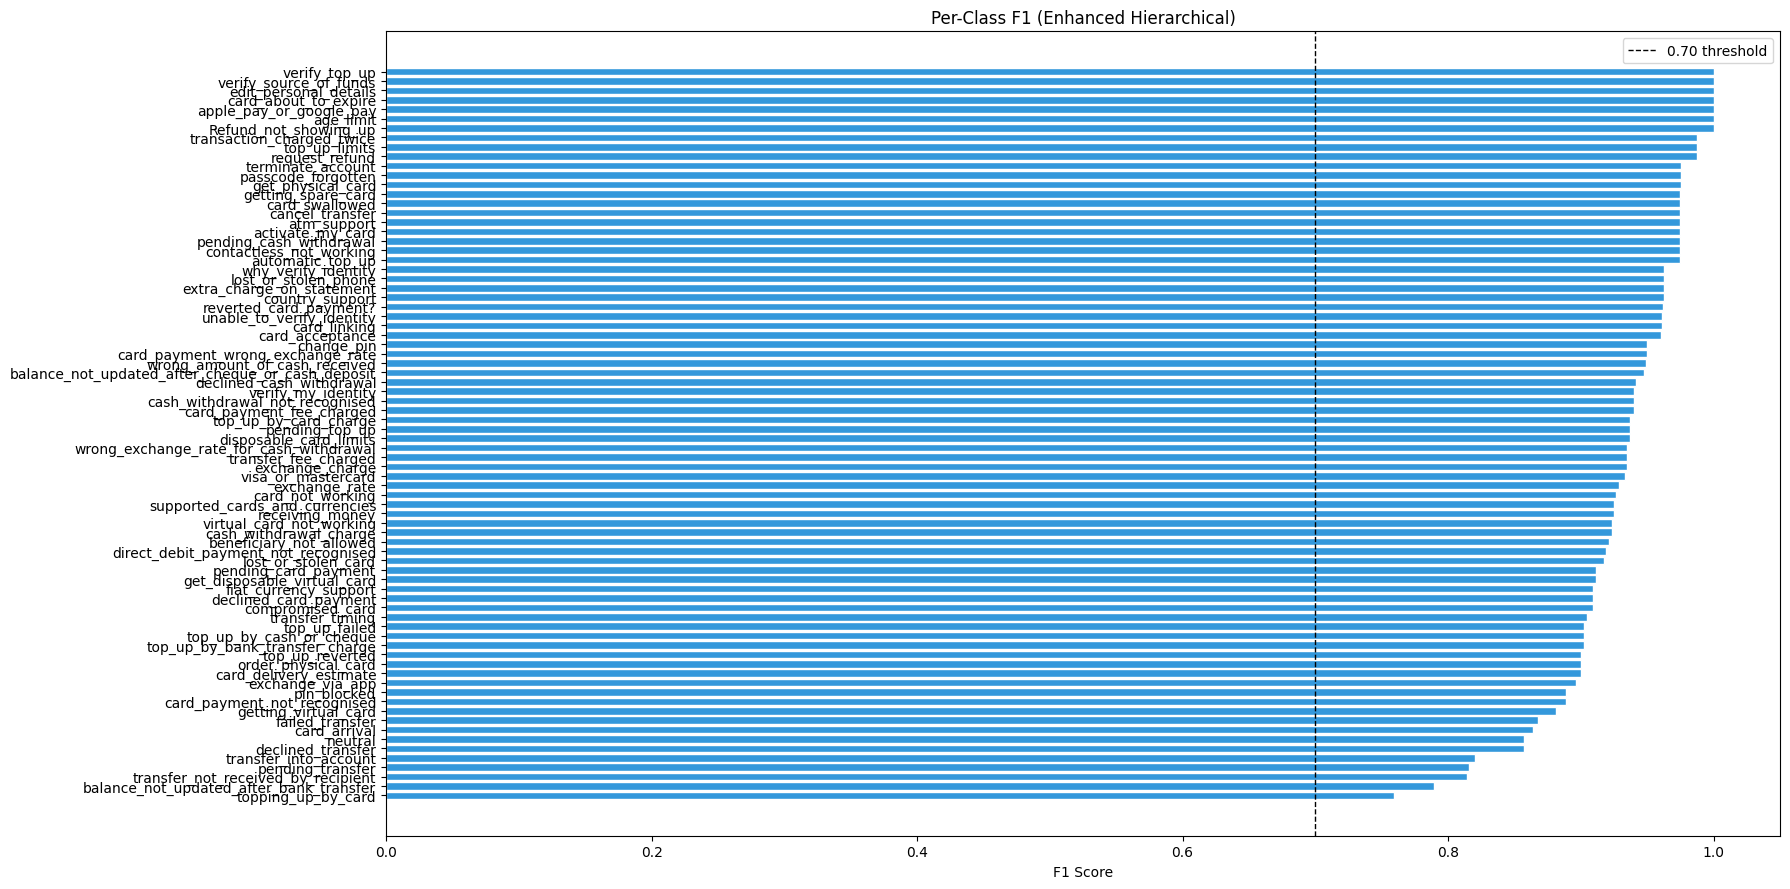

Classes with F1 < 0.70: 0


In [16]:
report_dict = classification_report(
    all_fine_labels, all_fine_preds,
    target_names=fine_le.classes_, output_dict=True
)

class_f1 = {
    k: v['f1-score']
    for k, v in report_dict.items()
    if k not in ('accuracy', 'macro avg', 'weighted avg')
}
class_f1_sorted = dict(sorted(class_f1.items(), key=lambda x: x[1]))

fig, ax = plt.subplots(figsize=(18, 9))
colors = ['#e74c3c' if v < 0.70 else '#3498db' for v in class_f1_sorted.values()]
ax.barh(list(class_f1_sorted.keys()), list(class_f1_sorted.values()),
        color=colors, edgecolor='white')
ax.axvline(0.70, color='black', linestyle='--', lw=1, label='0.70 threshold')
ax.set_xlabel('F1 Score'); ax.set_title('Per-Class F1 (Enhanced Hierarchical)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

weak = {k: v for k, v in class_f1_sorted.items() if v < 0.70}
print(f'Classes with F1 < 0.70: {len(weak)}')
for k, v in weak.items():
    print(f'  {k:<50} F1 = {v:.3f}')

## 13. Confusion Matrix — Top Confused Pairs

TOP 20 MOST CONFUSED PAIRS
                             True label                       Predicted as  Count  Error rate
balance_not_updated_after_bank_transfer transfer_not_received_by_recipient      5       0.125
                       pending_transfer transfer_not_received_by_recipient      5       0.125
                           card_arrival             card_delivery_estimate      4       0.100
balance_not_updated_after_bank_transfer                    transfer_timing      4       0.100
                      declined_transfer              declined_card_payment      4       0.100
                      declined_transfer                    failed_transfer      4       0.100
                 card_delivery_estimate                       card_arrival      4       0.100
                  fiat_currency_support                   exchange_via_app      4       0.100
            card_payment_not_recognised                   compromised_card      3       0.075
    direct_debit_payment_not_reco

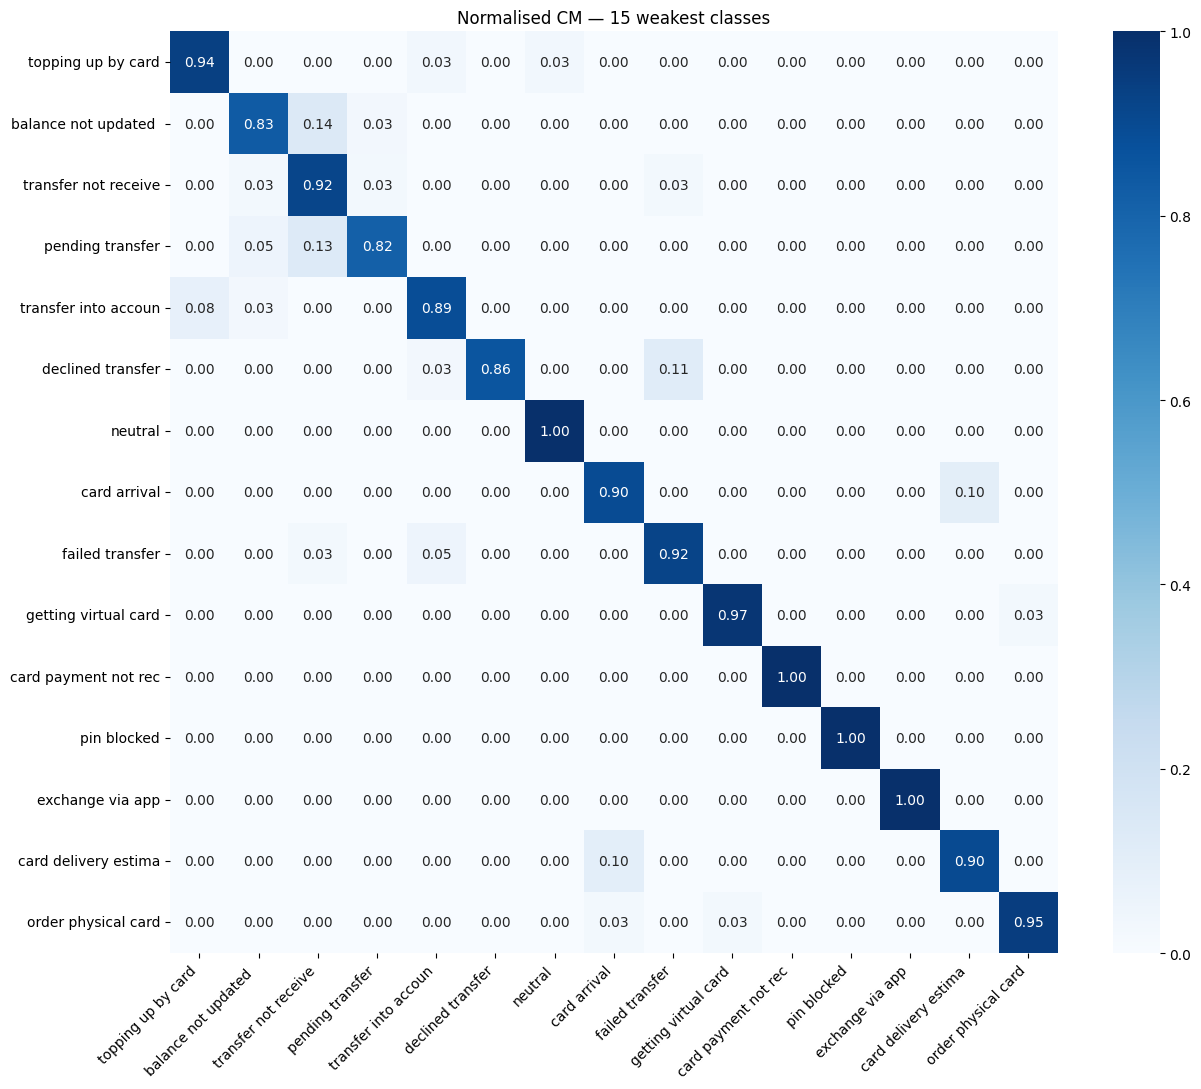

In [17]:
cm = confusion_matrix(all_fine_labels, all_fine_preds)

# Top confused pairs
confused_pairs = []
for i in range(len(fine_le.classes_)):
    for j in range(len(fine_le.classes_)):
        if i != j and cm[i, j] > 0:
            confused_pairs.append({
                'True label'  : fine_le.classes_[i],
                'Predicted as': fine_le.classes_[j],
                'Count'       : cm[i, j],
                'Error rate'  : round(cm[i, j] / cm[i].sum(), 3)
            })

confused_df = pd.DataFrame(confused_pairs).sort_values('Count', ascending=False).head(20)
confused_df.to_csv(f'{OUTPUT_DIR}/confused_pairs.csv', index=False)
print('TOP 20 MOST CONFUSED PAIRS')
print(confused_df.to_string(index=False))

# Weak-class heatmap
weak_names = list(class_f1_sorted.keys())[:15]
weak_ids   = [int(np.where(fine_le.classes_ == n)[0][0]) for n in weak_names]
cm_weak    = cm[np.ix_(weak_ids, weak_ids)].astype(float)
cm_weak   /= np.maximum(cm_weak.sum(axis=1, keepdims=True), 1)

short = [n.replace('_', ' ')[:20] for n in weak_names]
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(cm_weak, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=short, yticklabels=short, ax=ax)
ax.set_title('Normalised CM — 15 weakest classes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confusion_matrix_weak.png', dpi=150, bbox_inches='tight')
plt.show()

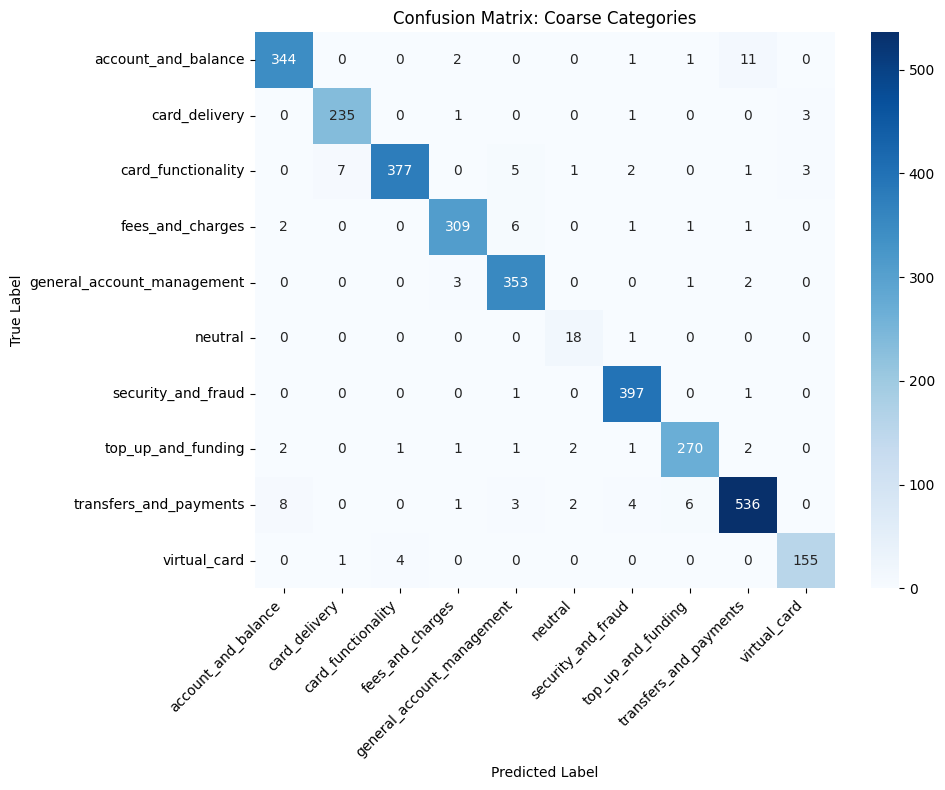

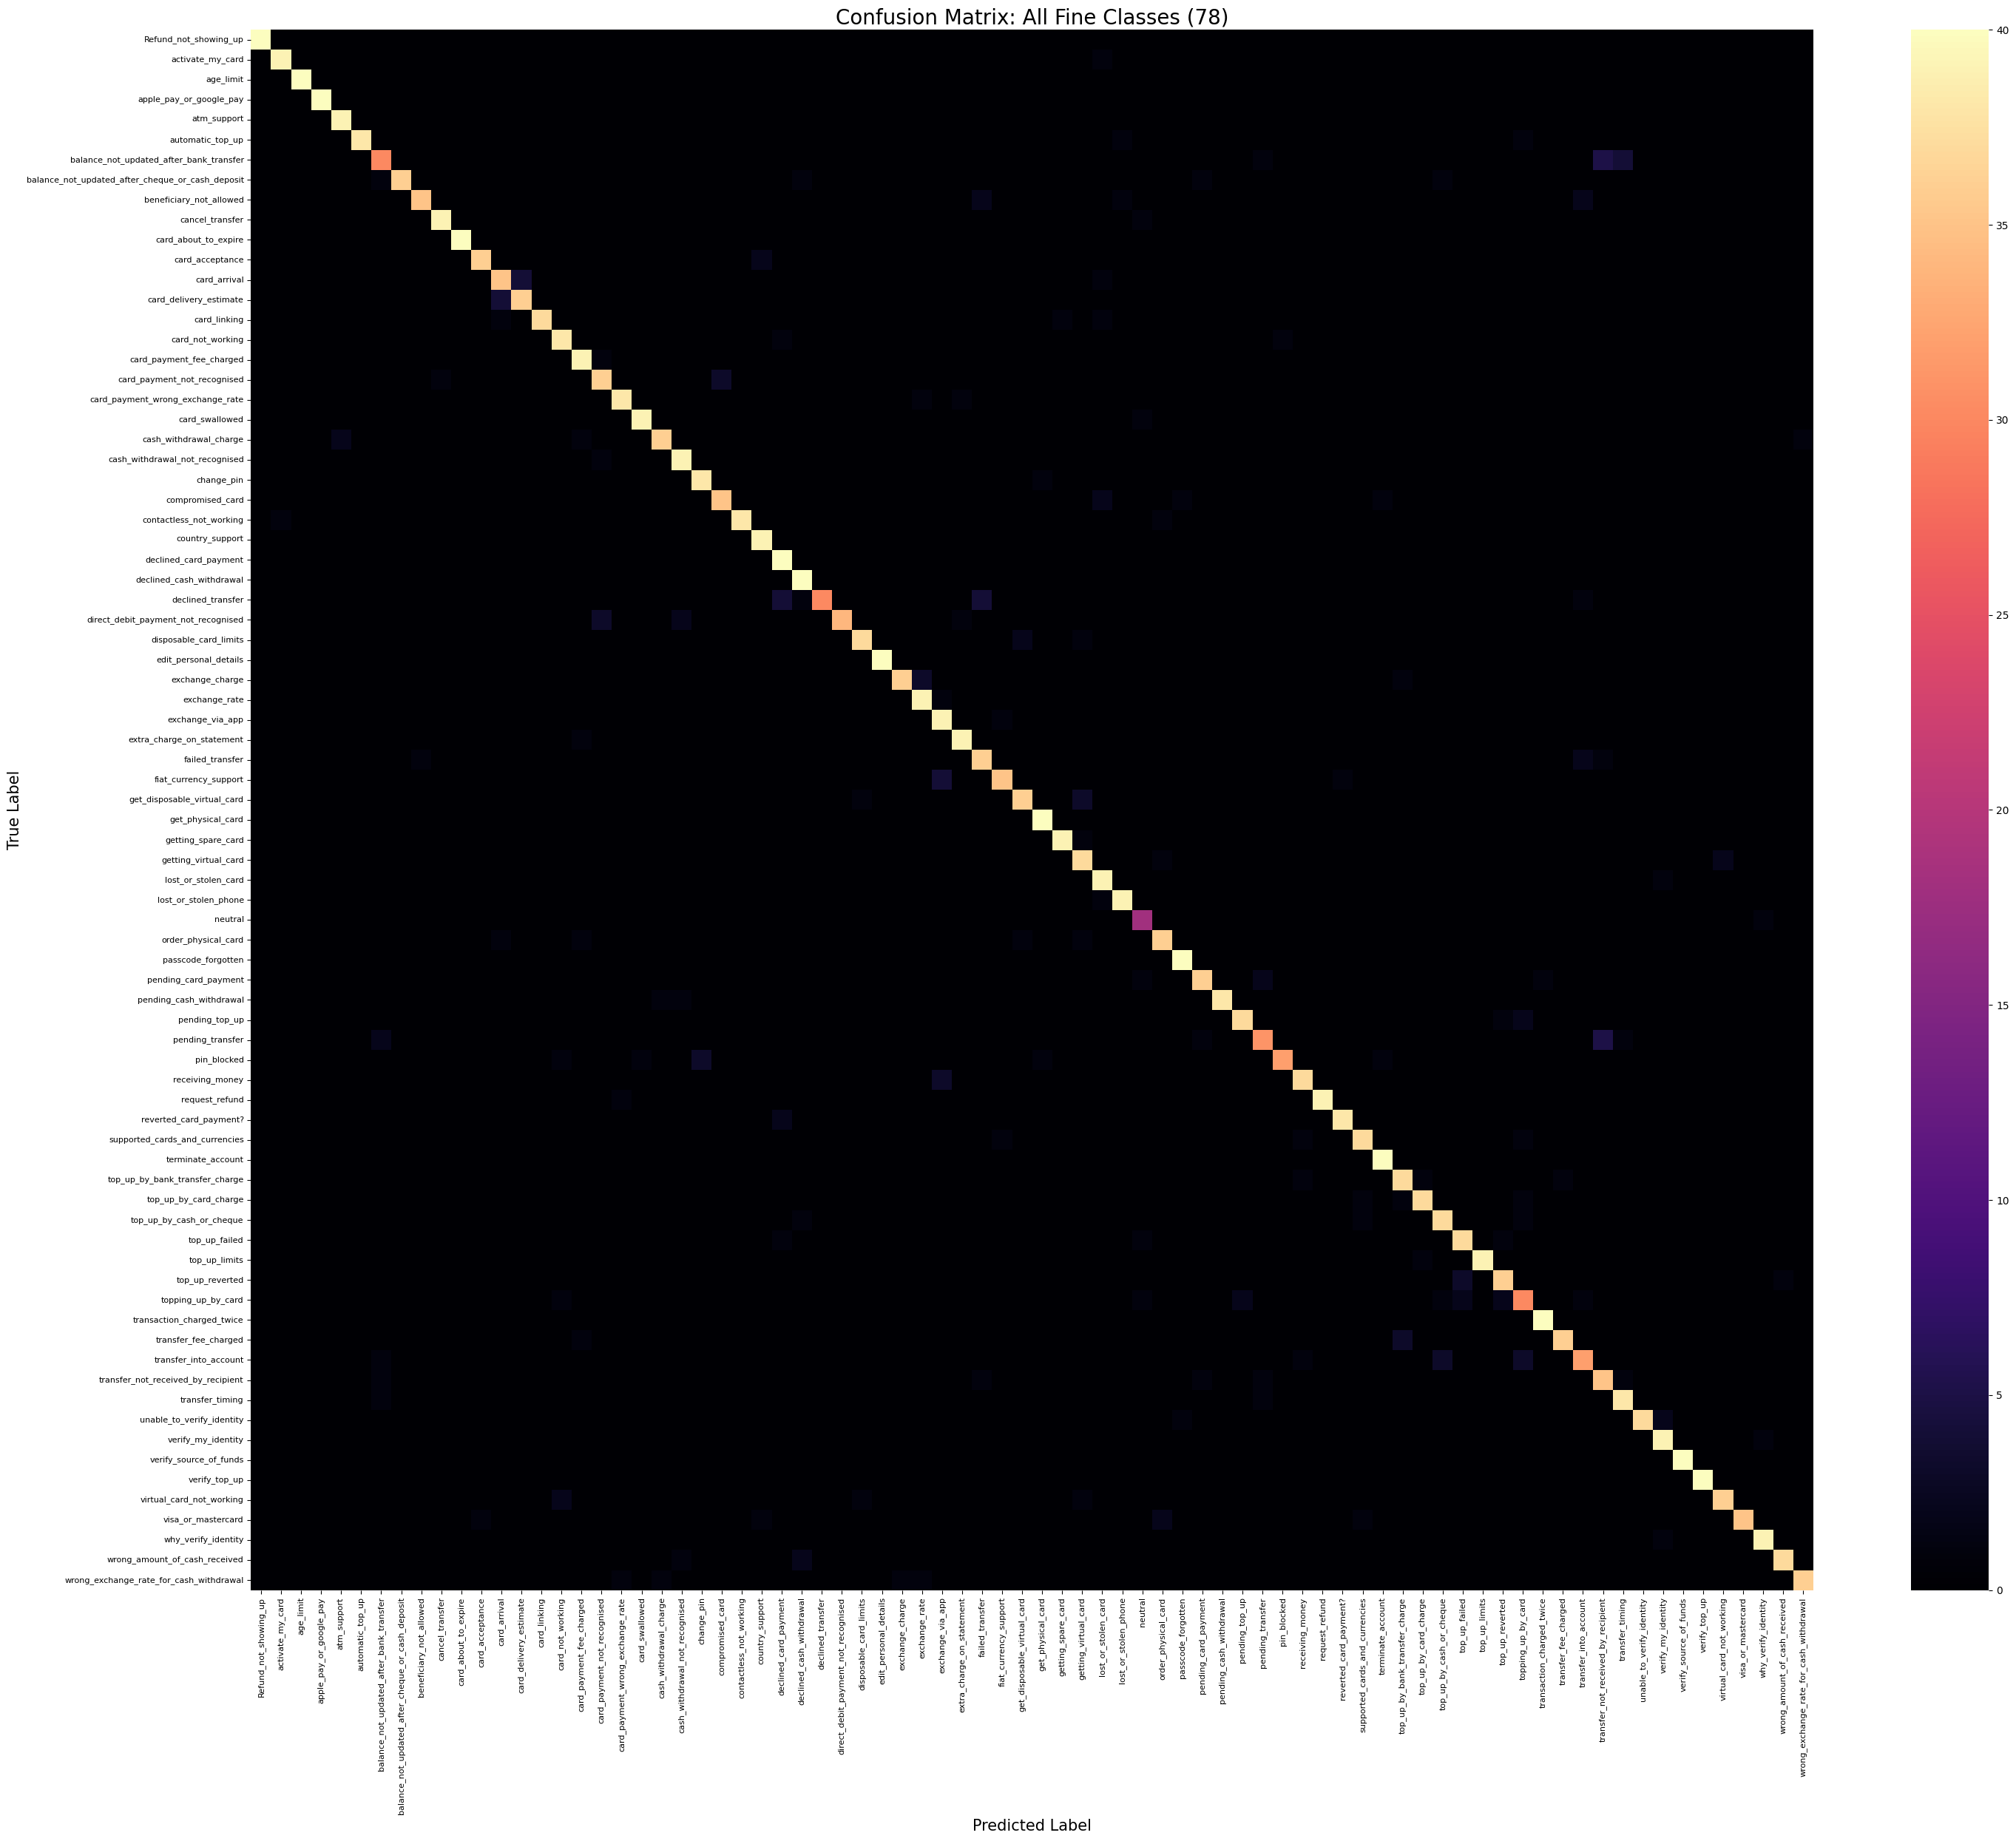

Matrices saved to /kaggle/working/enhanced_hierarchical


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrices(all_fine_labels, all_fine_preds, all_coarse_labels, all_coarse_preds, fine_le, coarse_le):
    # 1. Coarse Confusion Matrix (9 Classes)
    cm_coarse = confusion_matrix(all_coarse_labels, all_coarse_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_coarse, annot=True, fmt='d', cmap='Blues',
                xticklabels=coarse_le.classes_, 
                yticklabels=coarse_le.classes_)
    plt.title('Confusion Matrix: Coarse Categories')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/confusion_matrix_coarse.png', dpi=150)
    plt.show()

    # 2. All Classes Confusion Matrix (78 Fine Classes)
    cm_fine = confusion_matrix(all_fine_labels, all_fine_preds)
    # Note: With 78 classes, a standard plot is hard to read. 
    # We increase the size significantly for the saved file.
    plt.figure(figsize=(30, 25))
    sns.heatmap(cm_fine, annot=False, cmap='magma', # annot=False because numbers will overlap
                xticklabels=fine_le.classes_, 
                yticklabels=fine_le.classes_)
    plt.title('Confusion Matrix: All Fine Classes (78)', fontsize=20)
    plt.ylabel('True Label', fontsize=15)
    plt.xlabel('Predicted Label', fontsize=15)
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    
    # Save a high-resolution version to check details
    plt.savefig(f'{OUTPUT_DIR}/confusion_matrix_fine_full.png', dpi=300)
    plt.show()
    
    print(f"Matrices saved to {OUTPUT_DIR}")

# Call the function using variables from your evaluation cell
plot_confusion_matrices(
    all_fine_labels, all_fine_preds, 
    all_coarse_labels, all_coarse_preds, 
    fine_le, coarse_le
)

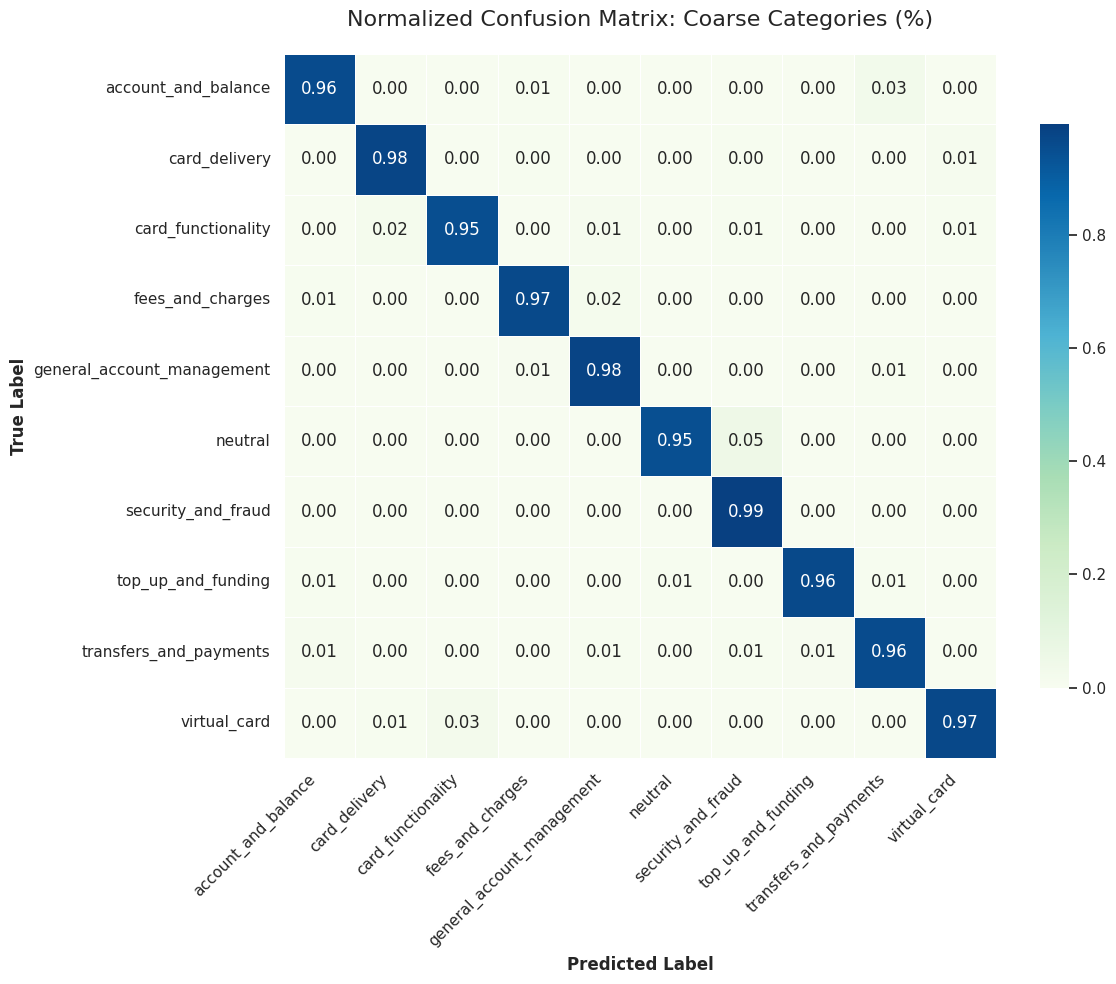

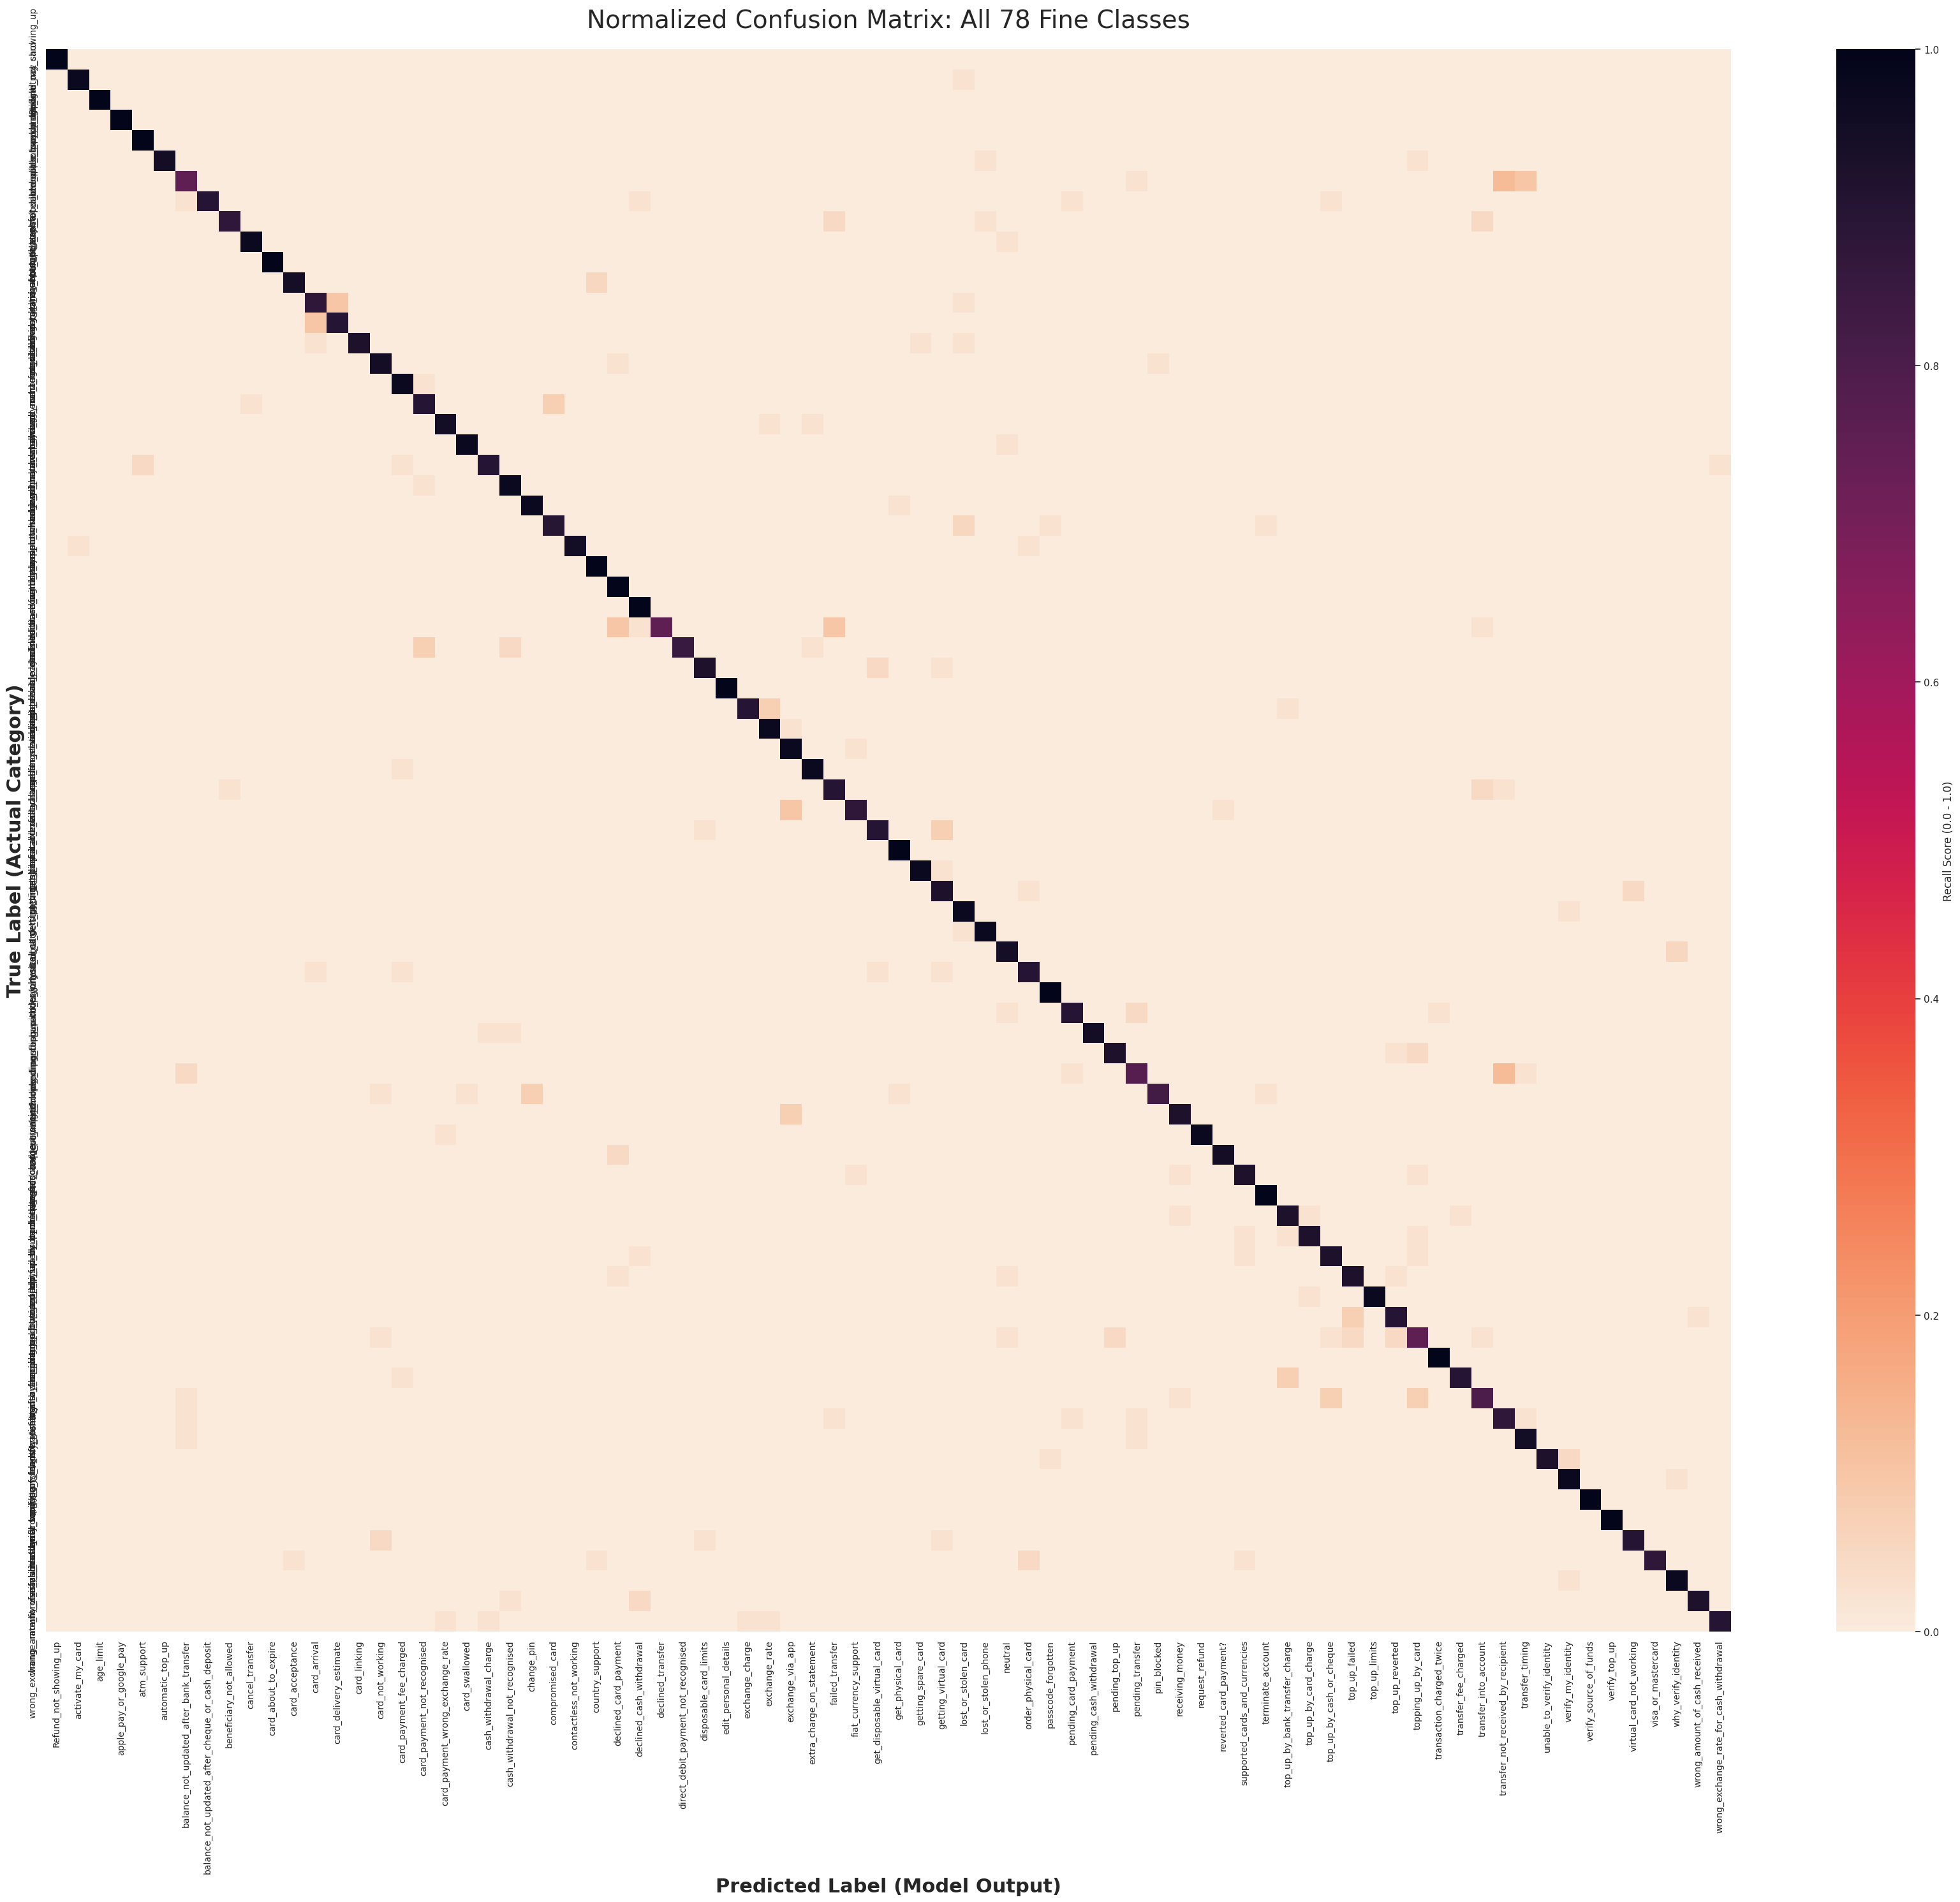

High-quality matrices saved to /kaggle/working/enhanced_hierarchical


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_normalized_confusion_matrices(all_fine_labels, all_fine_preds, all_coarse_labels, all_coarse_preds, fine_le, coarse_le):
    # Set the plotting style for a cleaner look
    sns.set_theme(style="white")

    # 1. Normalized Coarse Confusion Matrix (9 Classes)
    # Using 'GnBu' (Green to Blue) - excellent for readability with text annotations
    cm_coarse = confusion_matrix(all_coarse_labels, all_coarse_preds, normalize='true')
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm_coarse, annot=True, fmt='.2f', cmap='GnBu',
                xticklabels=coarse_le.classes_, 
                yticklabels=coarse_le.classes_,
                linewidths=.5, cbar_kws={"shrink": .8})
    
    plt.title('Normalized Confusion Matrix: Coarse Categories (%)', fontsize=16, pad=20)
    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/confusion_matrix_coarse_percent_v2.png', dpi=150)
    plt.show()

    # 2. Normalized Fine Confusion Matrix (All 78 Classes)
    # Using 'rocket_r' - Dark background makes the bright diagonal line "pop"
    # This is standard for large matrices to highlight the accuracy trend.
    cm_fine = confusion_matrix(all_fine_labels, all_fine_preds, normalize='true')
    
    plt.figure(figsize=(34, 30))
    sns.heatmap(cm_fine, annot=False, cmap='rocket_r', 
                cbar_kws={'label': 'Recall Score (0.0 - 1.0)'}) 
    
    plt.title('Normalized Confusion Matrix: All 78 Fine Classes', fontsize=28, pad=25)
    plt.ylabel('True Label (Actual Category)', fontsize=22, fontweight='bold')
    plt.xlabel('Predicted Label (Model Output)', fontsize=22, fontweight='bold')
    
    # Setting ticks for all 78 classes
    plt.xticks(np.arange(len(fine_le.classes_)) + 0.5, fine_le.classes_, rotation=90, fontsize=10)
    plt.yticks(np.arange(len(fine_le.classes_)) + 0.5, fine_le.classes_, fontsize=10)
    
    plt.tight_layout()
    
    # Save a super-high-res version for zooming in
    plt.savefig(f'{OUTPUT_DIR}/confusion_matrix_fine_percent_v2.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"High-quality matrices saved to {OUTPUT_DIR}")

# Execute using your evaluation variables
plot_normalized_confusion_matrices(
    all_fine_labels, all_fine_preds, 
    all_coarse_labels, all_coarse_preds, 
    fine_le, coarse_le
)

## 14. Error Analysis

In [18]:
results_df = test_df[['text', 'category', 'coarse_category']].copy()
results_df['predicted_fine']   = [fine_le.classes_[p] for p in all_fine_preds]
results_df['predicted_coarse'] = [id2coarse[p] for p in all_coarse_preds]
results_df['correct']          = results_df['category'] == results_df['predicted_fine']

errors_df = results_df[~results_df['correct']].reset_index(drop=True)

print(f'Total test samples   : {len(results_df):,}')
print(f'Correctly classified : {results_df["correct"].sum():,}  ({results_df["correct"].mean()*100:.2f}%)')
print(f'Misclassified        : {len(errors_df):,}  ({len(errors_df)/len(results_df)*100:.2f}%)')

# Coarse routing errors vs fine head errors
coarse_correct = [id2coarse[p] == r for p, r in zip(all_coarse_preds, results_df['coarse_category'].tolist())]
fine_errors    = results_df[~results_df['correct']]

# Among fine errors, how many had a wrong coarse prediction?
coarse_wrong_in_fine_errors = fine_errors[
    fine_errors['coarse_category'] != fine_errors['predicted_coarse']
]
print(f'\nFine errors caused by wrong coarse routing : {len(coarse_wrong_in_fine_errors)} / {len(fine_errors)}')
print(f'Fine errors despite correct coarse routing : {len(fine_errors) - len(coarse_wrong_in_fine_errors)} / {len(fine_errors)}')

# Sample misclassifications
print('\nSAMPLE MISCLASSIFICATIONS')
print('=' * 90)
for _, row in errors_df.sample(min(10, len(errors_df)), random_state=42).iterrows():
    print(f'  Text         : {row["text"]}')
    print(f'  True         : {row["category"]}  (coarse: {row["coarse_category"]})')
    print(f'  Predicted    : {row["predicted_fine"]}  (coarse: {row["predicted_coarse"]})')
    print()

Total test samples   : 3,092
Correctly classified : 2,882  (93.21%)
Misclassified        : 210  (6.79%)

Fine errors caused by wrong coarse routing : 98 / 210
Fine errors despite correct coarse routing : 112 / 210

SAMPLE MISCLASSIFICATIONS
  Text         : I need support options, I want to top my card
  True         : supported_cards_and_currencies  (coarse: general_account_management)
  Predicted    : topping_up_by_card  (coarse: top_up_and_funding)

  Text         : Am I able to exchange currencies?
  True         : fiat_currency_support  (coarse: general_account_management)
  Predicted    : exchange_via_app  (coarse: general_account_management)

  Text         : Can I get my card expedited?
  True         : card_delivery_estimate  (coarse: card_delivery)
  Predicted    : card_arrival  (coarse: card_delivery)

  Text         : I am getting continuous failure for all my transfers. I have cross checked each recipient detail again and again and everything is correct.
  True         : d

## 15. Save Artifacts

In [24]:
# Save model
m = model.module if hasattr(model, 'module') else model
torch.save(m.state_dict(), f'{OUTPUT_DIR}/dual_head_model.pt')
tokenizer.save_pretrained(f'{OUTPUT_DIR}/tokenizer')

# Save config with all metrics
config = {
    'model_name'         : MODEL_NAME,
    'max_len'            : MAX_LEN,
    'batch_size'         : BATCH_SIZE,
    'grad_accum'         : GRAD_ACCUM,
    'effective_batch'    : BATCH_SIZE * GRAD_ACCUM,
    'epochs_ran'         : epochs_ran,
    'label_smoothing'    : LABEL_SMOOTHING,
    'warmup_ratio'       : WARMUP_RATIO,
    'coarse_weight'      : COARSE_WEIGHT,
    'fine_weight'        : FINE_WEIGHT,
    'num_fine_classes'   : NUM_FINE,
    'num_coarse_classes' : NUM_COARSE,
    'test_fine_accuracy' : round(test_fine_acc, 4),
    'test_weighted_f1'   : round(test_weighted_f1, 4),
    'test_macro_f1'      : round(test_macro_f1, 4),
    'test_coarse_accuracy': round(test_coarse_acc, 4),
}

with open(f'{OUTPUT_DIR}/training_config.json', 'w') as f:
    json.dump(config, f, indent=2)

# Zip
shutil.make_archive('/kaggle/working/enhanced_hierarchical', 'zip', OUTPUT_DIR)
print('All artifacts saved.')
print(json.dumps(config, indent=2))

All artifacts saved.
{
  "model_name": "roberta-base",
  "max_len": 128,
  "batch_size": 16,
  "grad_accum": 2,
  "effective_batch": 32,
  "epochs_ran": 7,
  "label_smoothing": 0.1,
  "warmup_ratio": 0.1,
  "coarse_weight": 0.3,
  "fine_weight": 0.7,
  "num_fine_classes": 78,
  "num_coarse_classes": 10,
  "test_fine_accuracy": 0.9321,
  "test_weighted_f1": 0.932,
  "test_macro_f1": 0.9315,
  "test_coarse_accuracy": 0.9683
}


---
## Summary

| Metric | Original hierarchical | Enhanced hierarchical | BERT flat baseline |
|--------|-----------------------|-----------------------|--------------------|
| Fine accuracy | 90.75% | **93.21%** | 91.33% |
| Macro F1 | 0.9079 | **93.15%** | 0.9128 |
| Coarse accuracy | 94.11% | **96.83%** | — |
| Two models? | Yes (error propagation) | **No (shared encoder)** | No |
| Label smoothing | No | **Yes (0.1)** | No |
| LR schedule | Linear | **Cosine** | Linear |
| Effective batch | 16 | **32** | 32 |

**Key architectural change:** Single encoder → two heads → joint multi-task loss.  
This directly fixes the error-propagation problem where a wrong coarse prediction guaranteed a wrong fine prediction.